In [39]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

***1. Data Loading***


In [40]:
data_url = "https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv"

df = pd.read_csv(data_url)

print("First 5 rows:")
display(df.head())

print("Dataset shape:", df.shape)


First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Dataset shape: (614, 13)


In [41]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport( df , title=" Loan approval", explorative = True  )

profile.to_file("ydata.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 31.66it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

***2. Data Preprocessing***

In [42]:
#Missing Values
print("missing values: ")

df.isnull().sum()

missing values: 


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [43]:
#Drop Identifier Column
df = df.drop("Loan_ID", axis=1)

print("Columns after dropping Loan_ID:")
print(df.columns.tolist())

Columns after dropping Loan_ID:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


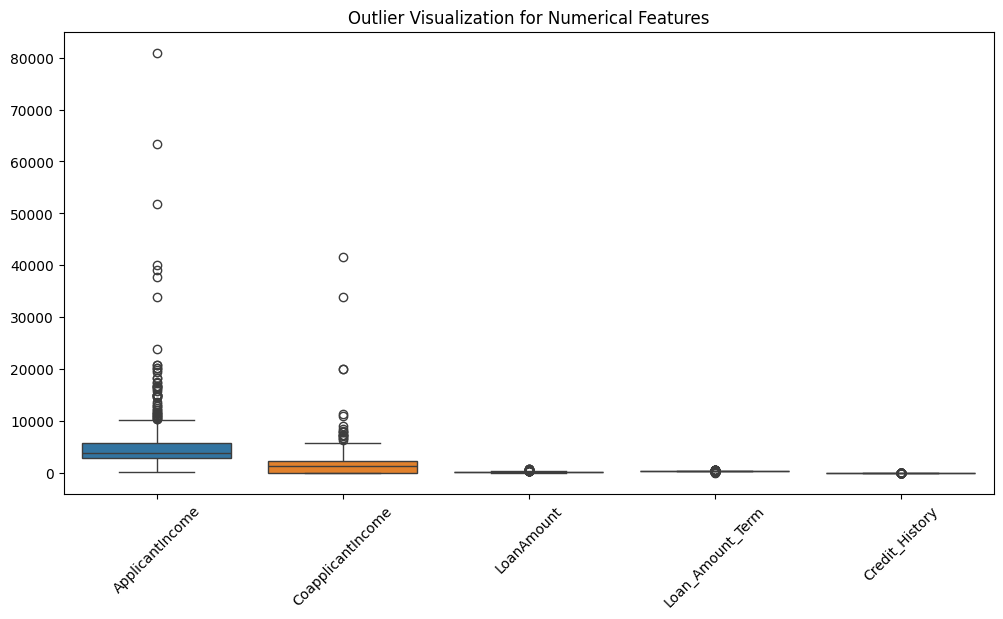

In [44]:
#Outlier
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Outlier Visualization for Numerical Features")
plt.show()

In [45]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (614, 11)
Target shape: (614,)


In [46]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


In [47]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (491, 11)
Test shape: (123, 11)


***3. Pipeline Creation***

In [49]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

**4. Primary Model Selection**

In [50]:
clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_rf = RandomForestClassifier(random_state=42)
clf_gb = GradientBoostingClassifier(random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', clf_lr),
        ('rf', clf_rf),
        ('gb', clf_gb)
    ],
    voting='hard'
)

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', clf_lr),
        ('rf', clf_rf),
        ('gb', clf_gb)
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

models_to_train = {
    "Logistic Regression": clf_lr,
    "Random Forest": clf_rf,
    "Gradient Boosting": clf_gb,
    "Voting Ensemble": voting_clf,
    "Stacking Ensemble": stacking_clf
}

In [51]:
results = []

for name, model in models_to_train.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)

print("Model Comparison Results:")
display(results_df)

Model Comparison Results:


,Model,Accuracy,Precision,Recall,F1 Score
4,Stacking Ensemble,0.869919,0.848485,0.988235,0.913043
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108
3,Voting Ensemble,0.845528,0.843750,0.952941,0.895028
1,Random Forest,0.821138,0.846154,0.905882,0.875000
2,Gradient Boosting,0.804878,0.821053,0.917647,0.866667


## Primary Model Selection

Random Forest Classifier is selected as the primary model because:

- It performs well on structured tabular data
- It can handle both numerical and encoded categorical features effectively
- It captures non-linear relationships
- It is robust and widely used in practical classification problems
- It often performs better than simple linear models when feature interactions are important

***5. Model Training***

In [52]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=2,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Initial Random Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Initial Random Forest Results
Accuracy : 0.8292682926829268
Precision: 0.8333333333333334
Recall   : 0.9411764705882353
F1 Score : 0.8839779005524862


***6. Cross-Validation***

In [53]:
cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Average CV Accuracy: {:.4f}".format(cv_scores.mean()))
print("Standard Deviation : {:.4f}".format(cv_scores.std()))

Cross-validation scores: [0.80487805 0.76422764 0.77235772 0.82113821 0.81147541]
Average CV Accuracy: 0.7948
Standard Deviation : 0.0224


***7. Hyperparameter Tuning***

In [54]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}

Best Cross-Validation Score:
0.8004122861265719


***8. Best Model Selection***

In [55]:
best_model = grid_search.best_estimator_
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(

***9. Model Performance Evaluation***

In [56]:
y_pred_best = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best)
rec = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print("Final Best Model Evaluation")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Final Best Model Evaluation
Accuracy : 0.8537
Precision: 0.8317
Recall   : 0.9882
F1 Score : 0.9032


In [57]:
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

           N       0.95      0.55      0.70        38
           Y       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



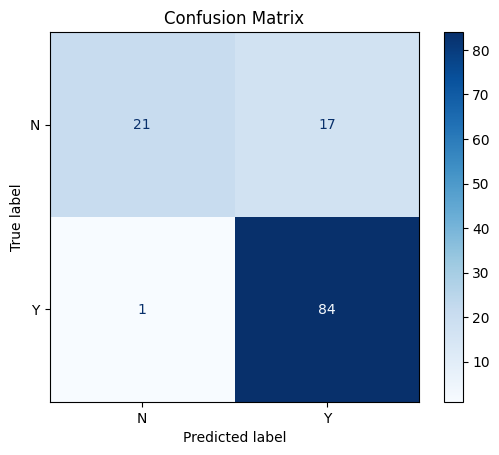

In [58]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [59]:
with open("best_loan_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Best model saved as best_loan_model.pkl")

with open("loan_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Label encoder saved as loan_label_encoder.pkl")

with open("best_loan_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

sample_pred = loaded_model.predict(X_test.iloc[:5])

print("Sample predictions:", sample_pred)
print("Actual labels     :", y_test[:5])

Best model saved as best_loan_model.pkl
Label encoder saved as loan_label_encoder.pkl
Sample predictions: [0 1 1 1 1]
Actual labels     : [0 1 1 1 1]


In [60]:
from google.colab import files
files.download("best_loan_model.pkl")
files.download("loan_label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>